In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import random
import scipy.linalg

import torch
import mctorch.nn as mnn
import mctorch.optim as moptim

#import autograd
#%set_env GEOMSTATS_BACKEND autograd
%set_env GEOMSTATS_BACKEND pytorch
import geomstats.backend as gs
from geomstats.geometry.euclidean import Euclidean
from geomstats.geometry.base import ImmersedSet
from geomstats.geometry.pullback_metric import (
    PullbackMetric,
    PullbackDiffeoMetric,
)

INFO: Using pytorch backend


env: GEOMSTATS_BACKEND=pytorch


In [2]:
X = pd.read_csv("Test1Mat.csv", header=None)
X = X.to_numpy()
Xt = X.transpose()
print(X.shape)

Xr = pd.read_csv("Test2Mat.csv", header=None)
Xr = Xr.to_numpy()
Xrt = Xr.transpose()
print(Xr.shape)

y = pd.read_csv("Labels.csv", header=None)
y = y.to_numpy().reshape(y.shape[1],)
print(y.shape)

(4096, 4)
(4096, 3)
(4096,)


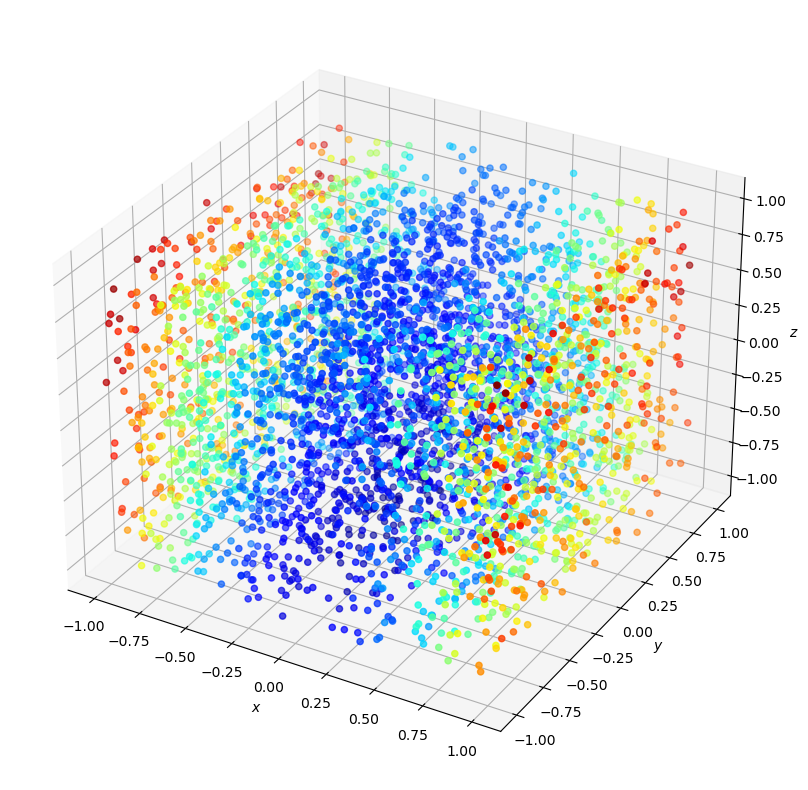

In [3]:
# Plot the dataset.
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.scatter(Xrt[0],Xrt[1],Xrt[2],c=y,cmap="jet")
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')
plt.show()

## Regression to learn f from the 3-d coords

In [4]:
# We could learn regression in 4-d, then pull back the function to 3d.
# But we're just trying to show how to learn isometric symmetries.

In [5]:
poly0 = PolynomialFeatures(2)

In [6]:
B = poly0.fit_transform(Xr)

In [7]:
def regress(B, y, criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD, lr=1e-2, n_epochs=5000):
    manifold_param = mnn.Parameter(manifold=mnn.Euclidean(B.shape[1]))
    Btensor = torch.tensor(B).float()
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat.float())
        return term1
    
    y = torch.tensor(y).float()
    
    optimizer = optimizer(params = [manifold_param], lr=lr)
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param

In [8]:
resultF = regress(B, y) #9*x0^2 + x1^2 + x2

In [9]:
resultF

(3.016855998794199e-06,
 Parameter containing:
 tensor([ 3.4885e-03, -8.0759e-06, -1.1083e-04,  9.9991e-01,  8.9960e+00,
          2.0316e-04, -3.4646e-04,  9.9734e-01,  8.2137e-05, -3.1835e-03],
        requires_grad=True))

## Pullback of the 4-d Euclidean metric

In [10]:
poly1 = PolynomialFeatures(2)

In [11]:
A = poly1.fit_transform(Xr)

In [12]:
poly1.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [13]:
A.shape

(4096, 10)

In [14]:
regress(A, X.transpose()[0]) #x=x0

(4.9993470696563236e-08,
 Parameter containing:
 tensor([-4.1849e-04,  1.0000e+00,  1.1601e-05,  6.0554e-06,  4.9115e-04,
         -8.3097e-06,  9.4715e-05,  1.4905e-04,  3.0454e-08,  5.3622e-04],
        requires_grad=True))

In [15]:
regress(A, X.transpose()[1]) #y=x1

(6.715105769217189e-07,
 Parameter containing:
 tensor([ 1.6620e-03, -1.0264e-05,  9.9995e-01, -3.9299e-05, -1.4849e-03,
          8.6514e-05, -1.5473e-04, -1.4055e-03,  5.6783e-05, -1.7849e-03],
        requires_grad=True))

In [16]:
regress(A, X.transpose()[2]) #z=x0^2+x1^2-x2

(2.7306433025842125e-07,
 Parameter containing:
 tensor([ 1.0552e-03, -3.9337e-06, -3.4046e-05, -1.0000e+00,  9.9891e-01,
          1.0821e-04, -4.8858e-05,  9.9898e-01,  4.0799e-05, -8.6126e-04],
        requires_grad=True))

In [17]:
regress(A, X.transpose()[3]) #t=2*x0

(1.2452596820367035e-07,
 Parameter containing:
 tensor([ 7.1295e-04,  2.0000e+00, -2.3176e-05, -2.1812e-05, -7.3037e-04,
          5.9933e-05, -2.6976e-05, -6.9841e-04,  2.7093e-05, -5.7829e-04],
        requires_grad=True))

In [18]:
#Now that we have written the 4-d coordinates as functions of the 3-d coordinates,
#we can pull back the 4-d Euclidean metric to obtain a metric on the 3-d space.
#We will need the christoffel symbols of the metric to compute the Killing vectors.

In [19]:
class BenManifold(ImmersedSet):
    def __init__(self, equip=True):
        super().__init__(dim=3, equip=equip)

    def immersion(self, point):
        u = point[..., 0]
        v = point[..., 1]
        w = point[..., 2]
        return gs.stack(
            [
                u,
                v,
                u**2+v**2-w,
                2*u,
            ],
            axis=-1,
        )

    def _define_embedding_space(self):
        return Euclidean(dim=self.dim + 1)

In [20]:
myManifold = BenManifold(equip=False)

myManifold.equip_with_metric(PullbackMetric)

In [21]:
Gamma = myManifold.metric.christoffels

In [22]:
Gamma(base_point=gs.array([0.0,0.0,0.0]))

tensor([[[ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.]],

        [[ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.]],

        [[-2.,  0.,  0.],
         [ 0., -2.,  0.],
         [ 0.,  0.,  0.]]])

## Estimate the Killing vectors

In [23]:
# will use this function twice. Once for the components of the vector field, and
# once for the jacobian of the (vector-valued, in general) function: like the gradient of the function.
def Jacf(params,featFunc,X): #stacked Jacobian matrix at each point in X
    #w = self.params
    dim = featFunc.n_features_in_
    from sympy import symbols
    from sympy import Matrix
    from sympy import lambdify
    # create sympy symbols.
    #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
    exec(",".join(featFunc.get_feature_names_out()[1:dim+1]) + '= symbols(" ".join(featFunc.get_feature_names_out()[1:dim+1]))')
    # Fix things: no x0^2 and such.
    p1 = ",".join(featFunc.get_feature_names_out())
    p2 = p1.replace(" ", "*")
    p3 = p2.replace("^", "**")
    p3a = eval(p3)
    p4 = Matrix(p3a)
    # Define the jacobian and make it a numpy array.
    J = p4.jacobian(Matrix(p3a[1:dim+1]))
    #print(J)
    Jnp = lambdify([p3a[1:dim+1]],J)
    #return Jnp
    
    jacs = []
    for x in X:
        #jacs.extend([self.params.transpose()@Jnp(x)])
        #jacs.extend([torch.matmul(torch.transpose(self.params), Jnp(x))])
        #print(torch.tensor(Jnp(x)))
        jacs.extend([torch.matmul(torch.transpose(torch.tensor(Jnp(x)).float(), 0, 1), params.float())])
            
    jacs = [torch.transpose(jac,0,1) for jac in jacs]
    #print(jacs[0].shape)
    bigJ = torch.stack(jacs, dim=0)
    #bigJ = np.array(jacs) #np.vstack(jacs)
    return bigJ

In [24]:
# will use this function twice. Once for the components of the vector field, and
# once for the jacobian of the (vector-valued, in general) function: like the gradient of the function.
def JacfG(params,featFunc,X): #stacked Jacobian matrix at each point in X
    #w = self.params
    dim = featFunc.n_features_in_
    from sympy import symbols
    from sympy import Matrix
    from sympy import lambdify
    # create sympy symbols.
    #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
    exec(",".join(featFunc.get_feature_names_out()[1:dim+1]) + '= symbols(" ".join(featFunc.get_feature_names_out()[1:dim+1]))')
    # Fix things: no x0^2 and such.
    p1 = ",".join(featFunc.get_feature_names_out())
    p2 = p1.replace(" ", "*")
    p3 = p2.replace("^", "**")
    p3a = eval(p3)
    p4 = Matrix(p3a)
    # Define the jacobian and make it a numpy array.
    J = p4.jacobian(Matrix(p3a[1:dim+1]))
    #print(J)
    Jnp = lambdify([p3a[1:dim+1]],J)
    #return Jnp
    
    jacs = []
    for x in X:
        #jacs.extend([self.params.transpose()@Jnp(x)])
        #jacs.extend([torch.matmul(torch.transpose(self.params), Jnp(x))])
        #print(torch.tensor(Jnp(x)))
        #jacs.extend([torch.matmul(torch.transpose(torch.tensor(Jnp(x)).float(), 0,1), params.float())])
        jacs.extend([torch.transpose(torch.tensor(Jnp(x)).float(), 0, 1)])
        
            
    jacs = [torch.transpose(jac,0,1) for jac in jacs]
    
    #print(jacs[0].shape)
    bigJ = torch.stack(jacs, dim=0)
    #return bigJ
    JacsG = []
    for i in range(X.shape[0]):
        jacsG = torch.tensordot(bigJ[i], myManifold.metric.cometric_matrix(gs.array(X[i])).float(),dims=([1],[0]))
        #jacsG = 1/2*torch.add(jacsG,torch.transpose(jacsG,0,1))
        JacsG.extend([jacsG])
    bigJG = torch.stack(JacsG, dim=0)
    
    return bigJG

In [25]:
# This is a memory hog. Can we fix this later?
# We use this to calculate the partial derivative (stacked) matrix: part of the covariant derivative.
# We also use this to calculate the extB matrix for term1 in the big function.
def getExtendedFeatureMatrix2(B,J,dim):
    n = B.shape[0]
    m = B.shape[1]
    ExtArray = []
    for j in range(n):
        newBthing = np.append(B[j],np.zeros((dim-1)*m))
        Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
        Barray = torch.tensor(Barray).float()
        thing = torch.matmul(J[j], Barray)
        #thing = np.dot(J[j],Barray)
        ExtArray.extend(thing)
        
        
    ExtArray = torch.stack(ExtArray, dim=0)
    #ExtArray = np.array(ExtArray)
    return ExtArray

In [26]:
'''# This is a memory hog. Can we fix this later?
# this is for NO DERIVATIVES
def getExtendedFeatureMatrix3(B,dim):
    n = B.shape[0]
    m = B.shape[1]
    J = torch.ones((1,dim))
    ExtArray = []
    for j in range(n):
        newBthing = np.append(B[j],np.zeros((dim-1)*m))
        Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
        Barray = torch.tensor(Barray).float()
        thing = torch.matmul(J, Barray)
        #thing = np.dot(J[j],Barray)
        ExtArray.extend(thing)
        
    ExtArray = torch.stack(ExtArray, dim=0)
    #ExtArray = np.array(ExtArray)
    return ExtArray'''

'# This is a memory hog. Can we fix this later?\n# this is for NO DERIVATIVES\ndef getExtendedFeatureMatrix3(B,dim):\n    n = B.shape[0]\n    m = B.shape[1]\n    J = torch.ones((1,dim))\n    ExtArray = []\n    for j in range(n):\n        newBthing = np.append(B[j],np.zeros((dim-1)*m))\n        Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])\n        Barray = torch.tensor(Barray).float()\n        thing = torch.matmul(J, Barray)\n        #thing = np.dot(J[j],Barray)\n        ExtArray.extend(thing)\n        \n    ExtArray = torch.stack(ExtArray, dim=0)\n    #ExtArray = np.array(ExtArray)\n    return ExtArray'

In [27]:
# This is what we need to contract with the christoffel symbols
def getVFAtAPoint(B,W,j,dim):
    n = B.shape[0]
    m = B.shape[1]
    J = torch.ones((1,dim-1))
    ExtArray = []
    newBthing = np.append(B[j],np.zeros((dim-1)*m))
    Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
    Barray = torch.tensor(Barray).float()
    ExtArray.extend(Barray)
        
    ExtArray = torch.stack(ExtArray, dim=0)
    thing2 = torch.matmul(ExtArray, W.float())
    return thing2 ##ExtArray

# This is what we need to contract with the christoffel symbols
def getVFAtAPoint2(B,j,dim):
    n = B.shape[0]
    m = B.shape[1]
    J = torch.ones((1,dim-1))
    ExtArray = []
    newBthing = np.append(B[j],np.zeros((dim-1)*m))
    Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
    Barray = torch.tensor(Barray).float()
    ExtArray.extend(Barray)
        
    ExtArray = torch.stack(ExtArray, dim=0)
    #thing2 = torch.matmul(ExtArray, W.float())
    return ExtArray

In [36]:
def tryDimV(extB, d=1, n_epochs=10000, criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=1e-2): #only d=1 is supported right now.
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(extB.shape[1],d))
    Btensor = extB.detach() #torch.tensor(B).float()
    Dim = 3 # this is temporary...
    # here are useful things for calculating term2: (how much of this should be computed beforehand?)
    
    ##testparams2 = torch.transpose(torch.tensor([[1.0 for i in range(Btensor.shape[1])]]),0,1) #make it more generic: not 60.
    ##tempparams = torch.transpose(testparams2.reshape((Dim,Btensor.shape[1]//Dim)),0,1) # 3 should be the dimension.
    ##testJG = JacfG(tempparams,polyX, Xr)
    
    #testBx = getExtendedFeatureMatrix2(Bxr,testJG,Dim) # 3 is the dimension
    
    # Here are useful things for calculating term3.
    print("Calculating the Christoffel symbols at each point...")
    gammas = [Gamma(base_point=gs.array(xr)) for xr in Xr]
    print("Done calculating the Christoffel symbols...")
    crapshot = [torch.tensordot(gammas[i].float(),getVFAtAPoint2(Bxr,i,3), dims=([1],[0])) for i in range(Xr.shape[0])]
    crapshot = [torch.tensordot(crapshot[i],myManifold.metric.cometric_matrix(gs.array(Xr[i])).float(),dims=([1],[0])) for i in range(Xr.shape[0])]
    crapshot = [1/2*torch.add(crap,torch.transpose(crap,0,2)) for crap in crapshot]
    #Gammas = torch.vstack(gammas)
    #print(Gammas.shape)
    
    #crapshot = [torch.tensordot(gammasS[i].float(),getVFAtAPoint2(Bxr,i,3), dims=([1],[0])) for i in range(Xr.shape[0])]
    #print(crapshot[0].shape)
    #crapshot = torch.vstack(crapshot)
    crapshot = torch.stack(crapshot, dim=0)
    #print(crapshot.shape)
    #crapshot = torch.norm(crapshot,dim=2)
    testJG = JacfG(1.0,polyX, Xr)
    
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat.float()) #this is the ordinary term: checking X(f) = 0. size: nXd
        # Now we compute term2, which comes from the partial derivatives        
        tempparams = torch.transpose(mat.reshape((Dim,Btensor.shape[1]//Dim,mat.shape[1])),0,1).float() # 3 should be the dimension.
        term2a = torch.tensordot(testJG, tempparams, dims=([1],[0]))
        term2 = 1/2*torch.add(term2a, torch.transpose(term2a,1,2))
        
        #term2 = testJG #torch.matmul(testBx, mat.float())
        #print(term2.shape)
        # Now we compute term3, which comes from the christoffel symbols
        #term3 = torch.matmul(Gammas.float(),mat)
        term3 = torch.tensordot(crapshot, mat.float(), dims=([2],[0]))
        #print(term3.shape)
        #term3 = term3.reshape(term3.shape[0],term3.shape[1],term3.shape[2])
        #print(term3.shape)
        # Now we add them up
        term4 = torch.add(term2,term3)
        #return term1.float(), term4.float()
        return term4.float()
    

    y1 = torch.zeros((B.shape[0],d)).float()
    y23 = torch.zeros((B.shape[0],Dim,Dim,d)).float()
    #opred = model(myans)
    #print(criterion(opred[0],y1))
    #print(criterion(opred[1],y23))
    
    optimizer = optimizer(params = [manifold_param], lr=lr)
    print("Beginning optimization...")
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        #loss = criterion(y_pred[0].float(), y1).float() + criterion(y_pred[1].float(), y23).float()
        loss = criterion(y_pred.float(), y23).float()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if epoch % 1000 == 0:
            print("Still optimizing...")
        
    print("Done.")
    return loss.item(), manifold_param

In [52]:
polyX = PolynomialFeatures(2) # features for the Killing vector components

In [53]:
Bxr = polyX.fit_transform(Xr) # feature matrix for Killing vector components

In [54]:
fParams = resultF[1].detach().reshape(resultF[1].shape[0], 1)
test2J = Jacf(fParams,poly0,Xr)

In [55]:
test2J.shape

torch.Size([4096, 1, 3])

In [56]:
extB = getExtendedFeatureMatrix2(Bxr, test2J, 3)

In [57]:
output = tryDimV(extB, 6)

Calculating the Christoffel symbols at each point...
Done calculating the Christoffel symbols...
Beginning optimization...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Still optimizing...
Done.


In [58]:
output[0]

0.010672465898096561

In [36]:
# degree 1 polynomial: #costs=[0.059, 0.146, 0.221, 0.288, 0.419]
# degree 2 polynomial: #costs=[0.016, 0.031, 0.071, 0.062, 0.72]
#degree 3 polynomial: #costs = [0.019, 0.038, 0.027, 0.037, 0.04, 0.044]
#no X(f)=0: #costs = [0.0007,0.0009,0.0012,0.0004,0.0009]
# degree 3 w/o invariant condition: [0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0022, 0.0024]. only 5 kv's?

In [37]:
# Need: extB, polyX, Xr, Bxr, 

In [38]:
'''def tryDimV(extB, d, n_epochs=10000, criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=1e-2):
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(extB.shape[1],d))
    Btensor = extB.detach() #torch.tensor(B).float()
    
    # here are useful things for calculating term2: (how much of this should be computed beforehand?)
    testparams2 = torch.transpose(torch.tensor([[1.0 for i in range(60)]]),0,1) #make it more generic: not 60.
    tempparams = testparams2.reshape((20,3)) # 3 should be the dimension.
    testJ = Jacf(tempparams,polyX, Xr)
    testBx = getExtendedFeatureMatrix2(Bxr,testJ,3) # 3 is the dimension
    # Here are useful things for calculating term3.
    print("Calculating the Christoffel symbols at each point...")
    gammas = [Gamma(base_point=gs.array(xr)) for xr in Xr]
    print("Done calculating the Christoffel symbols...")
    #Gammas = torch.vstack(gammas)
    #print(Gammas.shape)
    
    crapshot = [torch.matmul(gammas[i].float(),getVFAtAPoint2(Bxr,i,3)) for i in range(Xr.shape[0])]
    crapshot = torch.vstack(crapshot)
    crapshot = torch.norm(crapshot,dim=1)
    
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat.float()) #this is the ordinary term: checking X(f) = 0. size: nXd
        # Now we compute term2, which comes from the partial derivatives        
        term2 = torch.matmul(testBx, mat.float())
        # Now we compute term3, which comes from the christoffel symbols
        #term3 = torch.matmul(Gammas.float(),mat)
        term3 = torch.matmul(crapshot, mat.float())
        # Now we add them up
        term4 = torch.add(term2,term3)
        return term1, term4
    
    y1 = torch.zeros((B.shape[0],d))
    y23 = torch.zeros((3*B.shape[0],d))
    
    optimizer = optimizer(params = [manifold_param], lr=lr)
    print("Beginning optimization...")
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion (y_pred[0], y1) + criterion(y_pred[1], y23)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if epoch % 1000 == 0:
            print("Still optimizing...")
        
    print("Done.")
    return loss.item(), manifold_param'''

'def tryDimV(extB, d, n_epochs=10000, criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=1e-2):\n    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(extB.shape[1],d))\n    Btensor = extB.detach() #torch.tensor(B).float()\n    \n    # here are useful things for calculating term2: (how much of this should be computed beforehand?)\n    testparams2 = torch.transpose(torch.tensor([[1.0 for i in range(60)]]),0,1) #make it more generic: not 60.\n    tempparams = testparams2.reshape((20,3)) # 3 should be the dimension.\n    testJ = Jacf(tempparams,polyX, Xr)\n    testBx = getExtendedFeatureMatrix2(Bxr,testJ,3) # 3 is the dimension\n    # Here are useful things for calculating term3.\n    print("Calculating the Christoffel symbols at each point...")\n    gammas = [Gamma(base_point=gs.array(xr)) for xr in Xr]\n    print("Done calculating the Christoffel symbols...")\n    #Gammas = torch.vstack(gammas)\n    #print(Gammas.shape)\n    \n    crapshot = [torch.matmul(gammas[i].float(),get

## Now learn the symmetries of f using known Killing vectors.

In [39]:
def f(x):
    term = 9*x[0]**2 + x[1]**2 + x[2]
    return term

In [40]:
grads = np.array([scipy.optimize.approx_fprime(point, f) for point in Xr])

In [41]:
def myA2(X,grads):
    r1 = np.array([np.dot(np.array([-X[i][1], X[i][0], 0.0]), grads[i]) for i in range(len(grads))])
    r2 = np.array([np.dot(np.array([0.0, -X[i][2], X[i][1]]), grads[i]) for i in range(len(grads))])
    r3 = np.array([np.dot(np.array([X[i][2], 0.0, -X[i][0]]), grads[i]) for i in range(len(grads))])
    #r1 = np.array([np.dot(np.array([X[i][0]**2+X[i][1]**2-X[i][2], 0.0, 2*X[i][0]**3+2*X[i][0]*X[i][1]**2-2*X[i][0]*X[i][2]+5*X[i][0]]), grads[i]) for i in range(len(grads))])
    #r2 = np.array([np.dot(np.array([0.0, X[i][0]**2+X[i][1]**2-X[i][2], 2*X[i][1]**3+2*X[i][1]*X[i][0]**2-2*X[i][1]*X[i][2]+X[i][0]]), grads[i]) for i in range(len(grads))])
    #r3 = np.array([np.dot(np.array([0.0, 0.0, 1.0]), grads[i]) for i in range(len(grads))])
    #r4 = np.array([np.dot(np.array([-X[i][1], 5*X[i][0], 8*X[i][0]*X[i][1]]), grads[i]) for i in range(len(grads))])
    #r5 = np.array([np.dot(np.array([0.0, 1.0, 2*X[i][1]]), grads[i]) for i in range(len(grads))])
    #r6 = np.array([np.dot(np.array([1.0, 0.0, 2*X[i][0]]), grads[i]) for i in range(len(grads))])
    #myMat = np.array([ [np.dot(np.array([0.0,-x[2],x[1]]),f.gradf(x))],
     #                  [np.dot(np.array([x[2],0.0,-x[0]]),f.gradf(x))],
      #                 [np.dot(np.array([-x[1],x[0],0.0]),f.gradf(x))] for x in X])
    #myMat = np.array([r1,r2,r3,r4,r5,r6]).transpose()
    #myMat = np.array([r1,r2,r3,r4,r5,r6]).transpose()
    myMat = np.array([r1,r2,r3]).transpose()
    return myMat

In [42]:
A2 = myA2(Xr,grads)

In [43]:
A2.shape

(4096, 6)

In [46]:
def tryDimV(extB, d, criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, n_epochs=5000):
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(extB.shape[1],d))
    Btensor = torch.tensor(extB).float() #extB.detach()
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat.float())
        #term2 = torch.norm(term1)
        #return term2
        return term1
    
    y = torch.zeros((extB.shape[0],d))
    
    optimizer = optimizer(params = [manifold_param], lr=1e-2)
    #optimizer = moptim.rAdagrad(params = [manifold_param], lr=1e-2)
    #optimizer = moptim.rSGD(params = [manifold_param], lr=1e-2)
    #criterion = torch.nn.L1Loss() #torch.nn.MSELoss()
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param

In [47]:
t1 = tryDimV(A2, 1)

In [48]:
t1

(0.002764499746263027,
 Parameter containing:
 tensor([[-6.6098e-05],
         [-6.9189e-05],
         [-1.4976e-07],
         [-1.0000e+00],
         [-6.7851e-05],
         [-7.7522e-05]], requires_grad=True))

## Can we express this in the original coordinates?

In [49]:
#We can use the push forward of (x,y,z,t)(x0,x1,x2), but the coefficients
#of the vectors would be in terms of (x0,x1,x2). Can we learn the "inverse?"
#it's not clear whether we need this or not.

In [50]:
def valsAtPoints(Xr):
    bigMat = np.array([[-Xr[i][1], 5*Xr[i][0], 8*Xr[i][0]*Xr[i][1]] for i in range(Xr.shape[0])])
    return bigMat

In [51]:
m1 = valsAtPoints(Xr)

In [52]:
m1.shape

(4096, 3)

In [53]:
poly3 = PolynomialFeatures(1)

In [54]:
B2 = poly3.fit_transform(X)

In [55]:
poly3.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x3'], dtype=object)

In [56]:
poly1.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [57]:
regress(A, m1.transpose()[0]) #-x1

(4.505889705797017e-08,
 Parameter containing:
 tensor([-3.8983e-04,  4.3812e-06, -9.9999e-01,  3.8997e-06,  2.4472e-04,
          2.8373e-05,  5.7278e-05,  2.2558e-04, -8.8686e-06,  6.2355e-04],
        requires_grad=True))

In [58]:
regress(A, m1.transpose()[1]) #5*x0

(2.9823863201272616e-07,
 Parameter containing:
 tensor([-1.1086e-03,  5.0000e+00,  3.4842e-05,  3.1733e-05,  1.0721e-03,
         -8.6396e-05,  6.6330e-05,  1.0667e-03, -5.1369e-05,  9.8222e-04],
        requires_grad=True))

In [59]:
regress(A, m1.transpose()[2]) #8*x0*x1

(3.4046081509586656e-08,
 Parameter containing:
 tensor([-3.3222e-04, -9.7828e-07,  9.7272e-06,  1.2197e-05,  2.4205e-04,
          7.9998e+00, -1.0322e-06,  4.8942e-04, -4.5498e-05,  2.0797e-04],
        requires_grad=True))

In [60]:
#There's a gap here, since we're computing the pushforward with Maple.

In [61]:
def valsAtPoints2(Xr):
    bigMat = np.array([[-Xr[i][1], 5*Xr[i][0], 0.0, -2*Xr[i][1]] for i in range(Xr.shape[0])])
    return bigMat

In [62]:
m2 = valsAtPoints2(Xr)

In [63]:
regress(B2, m2.transpose()[0], criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD) #-y

(5.626661462295802e-16,
 Parameter containing:
 tensor([-6.5951e-10, -9.4314e-01, -1.0000e+00,  4.9737e-09,  4.7157e-01],
        requires_grad=True))

In [64]:
regress(B2, m2.transpose()[1], criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD) #5*x. Or 2.5*t

(2.100116887576546e-14,
 Parameter containing:
 tensor([-6.4128e-10,  2.1745e+00,  2.8049e-08, -2.5554e-09,  1.4127e+00],
        requires_grad=True))

In [65]:
regress(B2, m2.transpose()[2], criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD) #0

(2.36893712048678e-18,
 Parameter containing:
 tensor([-1.7767e-11,  9.3724e-01,  2.1926e-09,  1.9004e-09, -4.6862e-01],
        requires_grad=True))

In [66]:
regress(B2, m2.transpose()[3], criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD) #-2y

(1.4307907962056638e-15,
 Parameter containing:
 tensor([ 2.3347e-10,  7.3963e-01, -2.0000e+00,  1.1225e-09, -3.6982e-01],
        requires_grad=True))

In [67]:
# t=2x, which makes this a bit tricky to pin down exactly...
# but at each point in this dataset, the vector field should be accurate.